In [1]:
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from model_utils import *
from pokemon_dataset import PokemonDataset
from cnn_class import CNN

(null): No such file or directory


In [2]:
DATA_DIR    = "Pokemon"
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=IMG_SIZE, scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
 
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


Found 1000 images | 20 classes: ['001 - Bulbasaur', '002 - Ivysaur', '003 - Venusaur', '004 - Charmander', '005 - Charmeleon', '006 - Charizard', '007 - Squirtle', '008 - Wartortle', '009 - Blastoise', '010 - Caterpie', '011 - Metapod', '012 - Butterfree', '013 - Weedle', '014 - Kakuna', '015 - Beedrill', '016 - Pidgey', '017 - Pidgeotto', '018 - Pidgeot', '019 - Rattata', '020 - Raticate']

Fold 1/5
  Epoch 01/20 | Train Loss: 11.2846 Acc: 0.0387 | Val Loss: 3.0765 Acc: 0.0550
  Epoch 02/20 | Train Loss: 3.1002 Acc: 0.0525 | Val Loss: 2.9888 Acc: 0.0950
  Epoch 03/20 | Train Loss: 3.0039 Acc: 0.0462 | Val Loss: 2.9970 Acc: 0.0500
  Epoch 04/20 | Train Loss: 3.0001 Acc: 0.0462 | Val Loss: 3.0011 Acc: 0.0500
  Epoch 05/20 | Train Loss: 3.0053 Acc: 0.0413 | Val Loss: 2.9929 Acc: 0.0500
  Epoch 06/20 | Train Loss: 2.9982 Acc: 0.0500 | Val Loss: 2.9900 Acc: 0.0500
  Epoch 07/20 | Train Loss: 3.0017 Acc: 0.0512 | Val Loss: 2.9639 Acc: 0.0650
  Epoch 08/20 | Train Loss: 3.0194 Acc: 0.0550 | 

/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

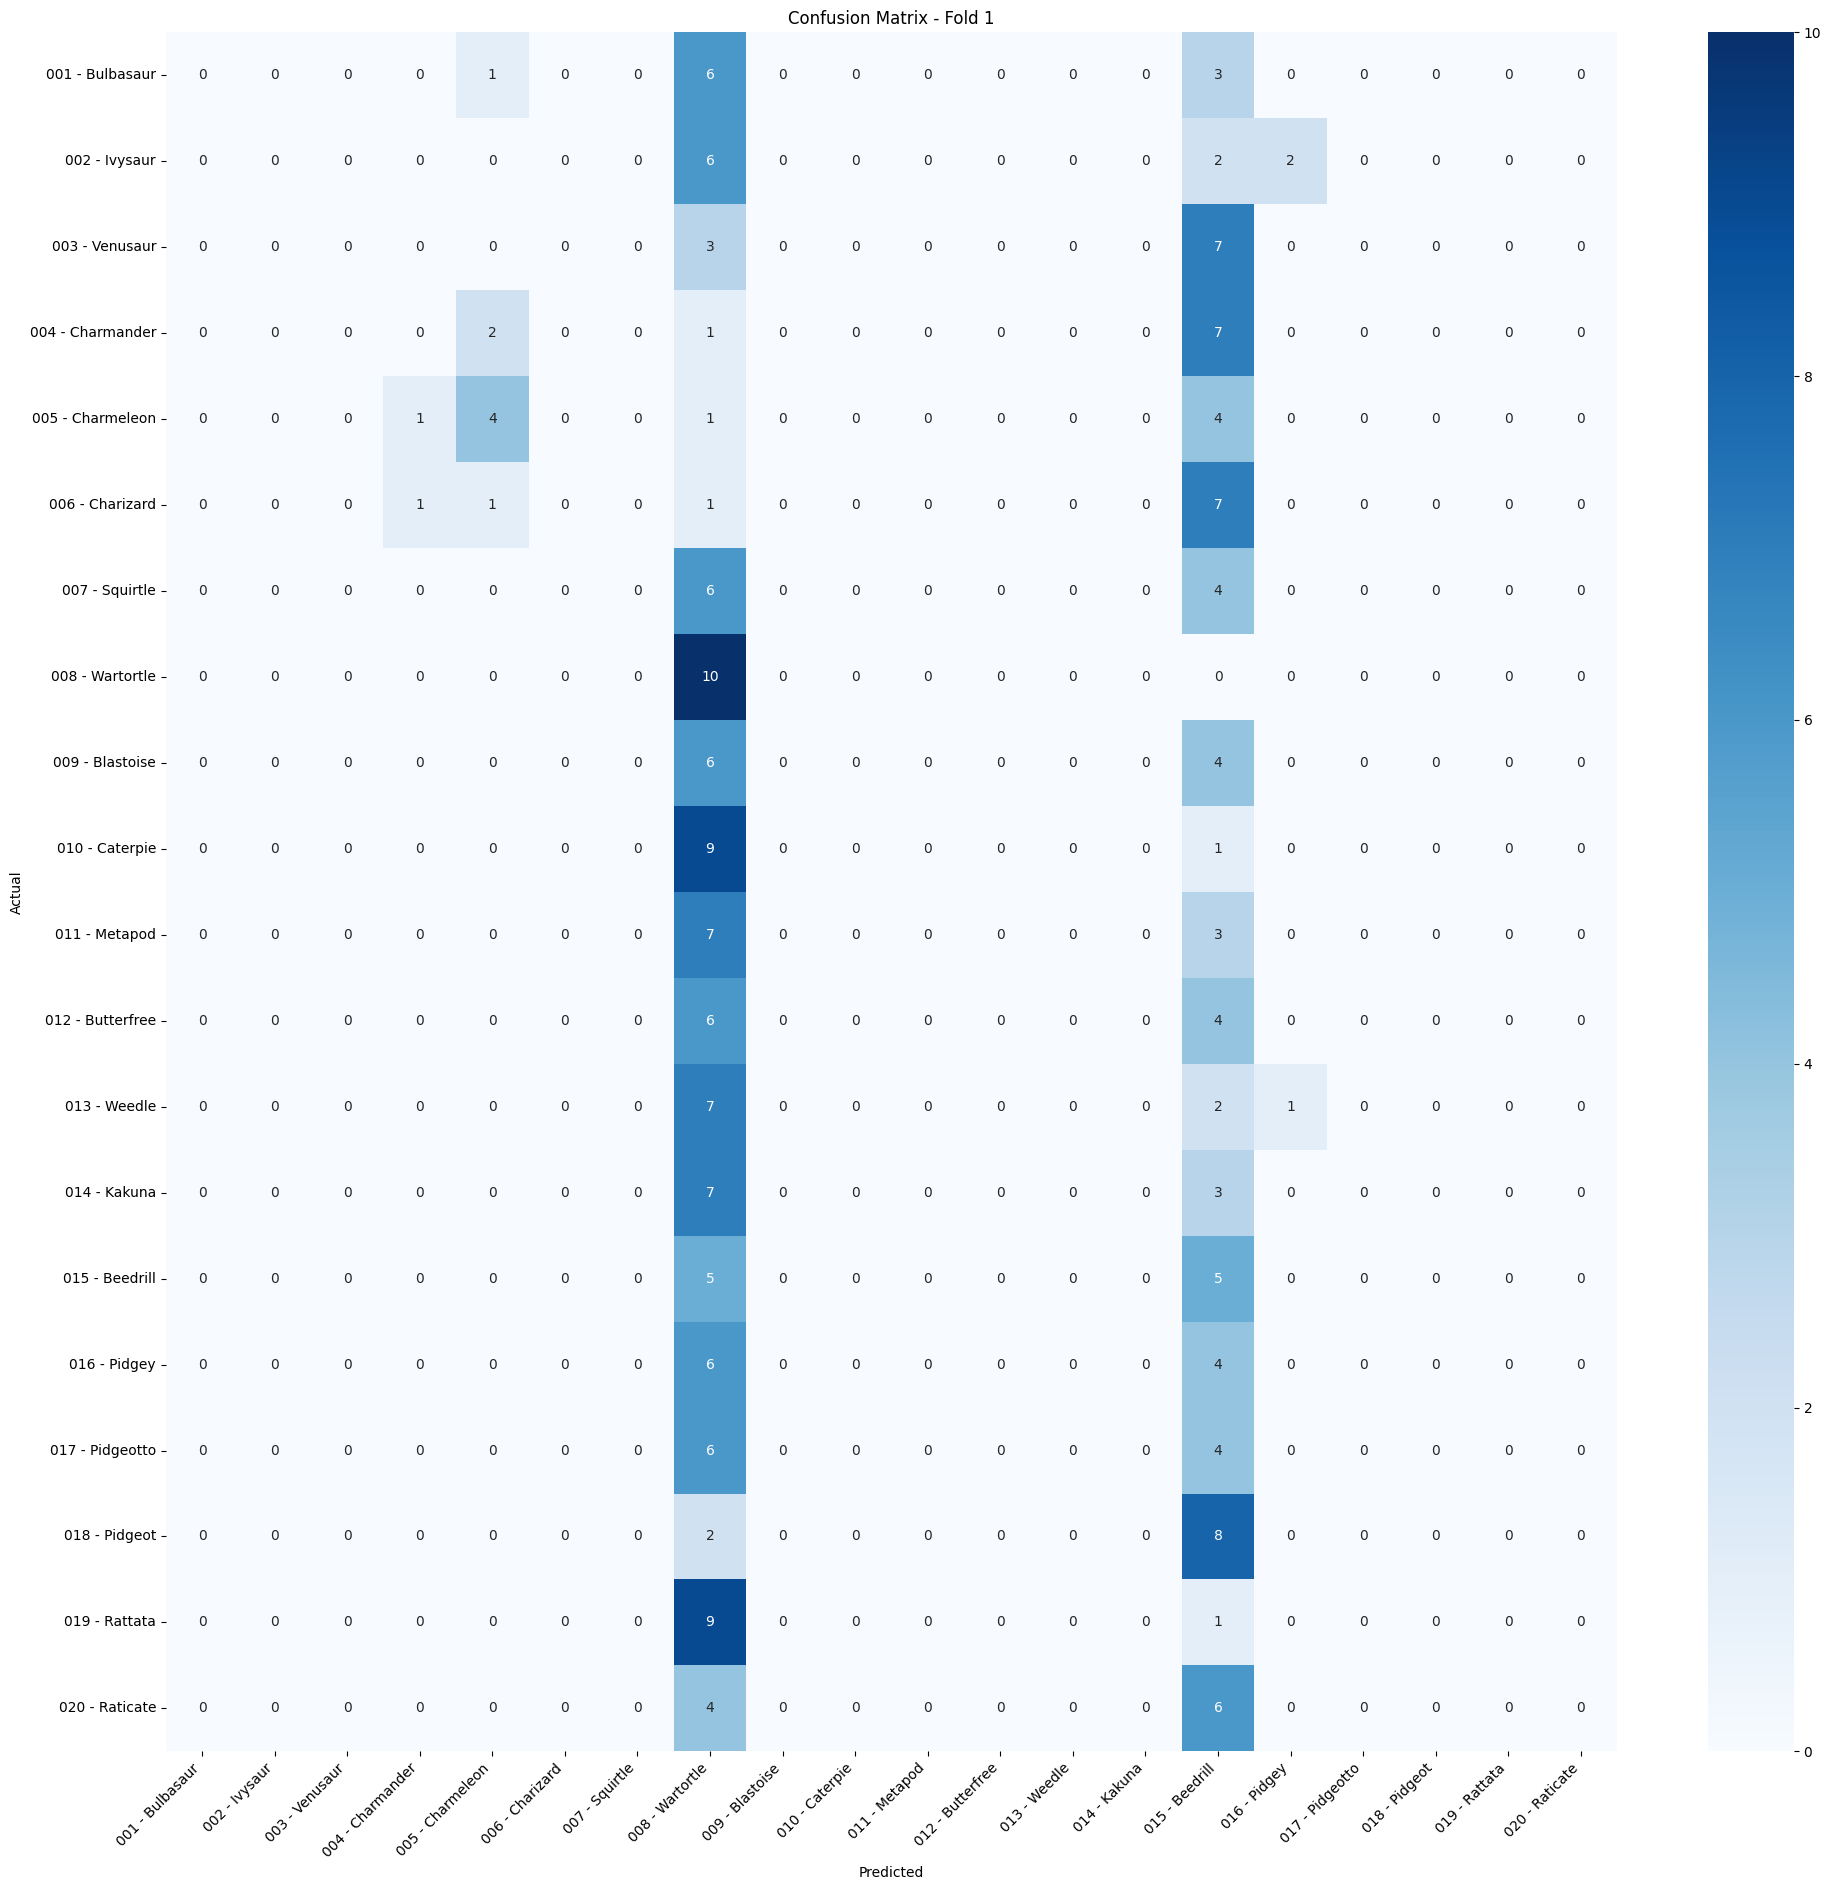

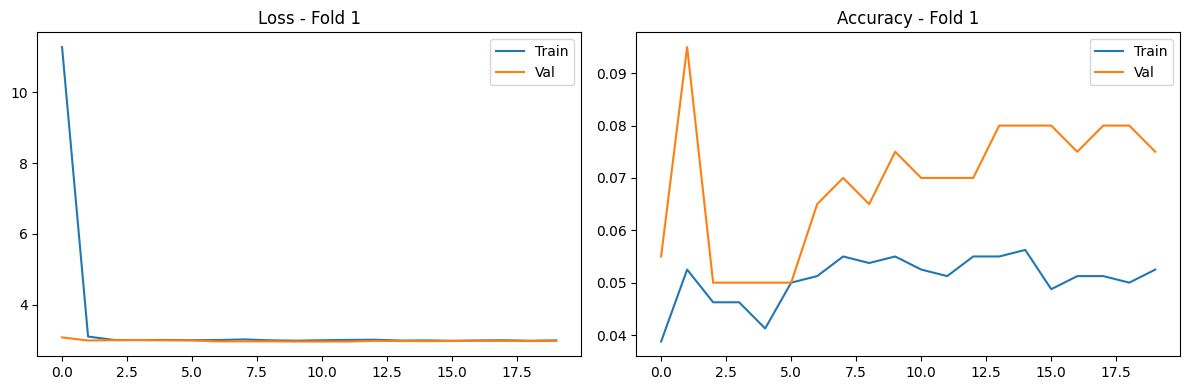

Fold 2/5
  Epoch 01/20 | Train Loss: 9.7667 Acc: 0.0387 | Val Loss: 3.5652 Acc: 0.0550
  Epoch 02/20 | Train Loss: 3.0763 Acc: 0.0500 | Val Loss: 2.9984 Acc: 0.0450
  Epoch 03/20 | Train Loss: 2.9982 Acc: 0.0525 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 04/20 | Train Loss: 2.9972 Acc: 0.0475 | Val Loss: 2.9961 Acc: 0.0500
  Epoch 05/20 | Train Loss: 3.0012 Acc: 0.0525 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 06/20 | Train Loss: 2.9973 Acc: 0.0500 | Val Loss: 2.9935 Acc: 0.0550
  Epoch 07/20 | Train Loss: 2.9975 Acc: 0.0437 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 08/20 | Train Loss: 2.9962 Acc: 0.0425 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 09/20 | Train Loss: 2.9957 Acc: 0.0525 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 10/20 | Train Loss: 2.9961 Acc: 0.0512 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 11/20 | Train Loss: 2.9961 Acc: 0.0437 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 12/20 | Train Loss: 2.9959 Acc: 0.0362 | Val Loss: 2.9960 Acc: 0.0500
  Epoch 13/20 | Train Loss: 2.9960 Acc: 0.0462 | Val Lo

/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

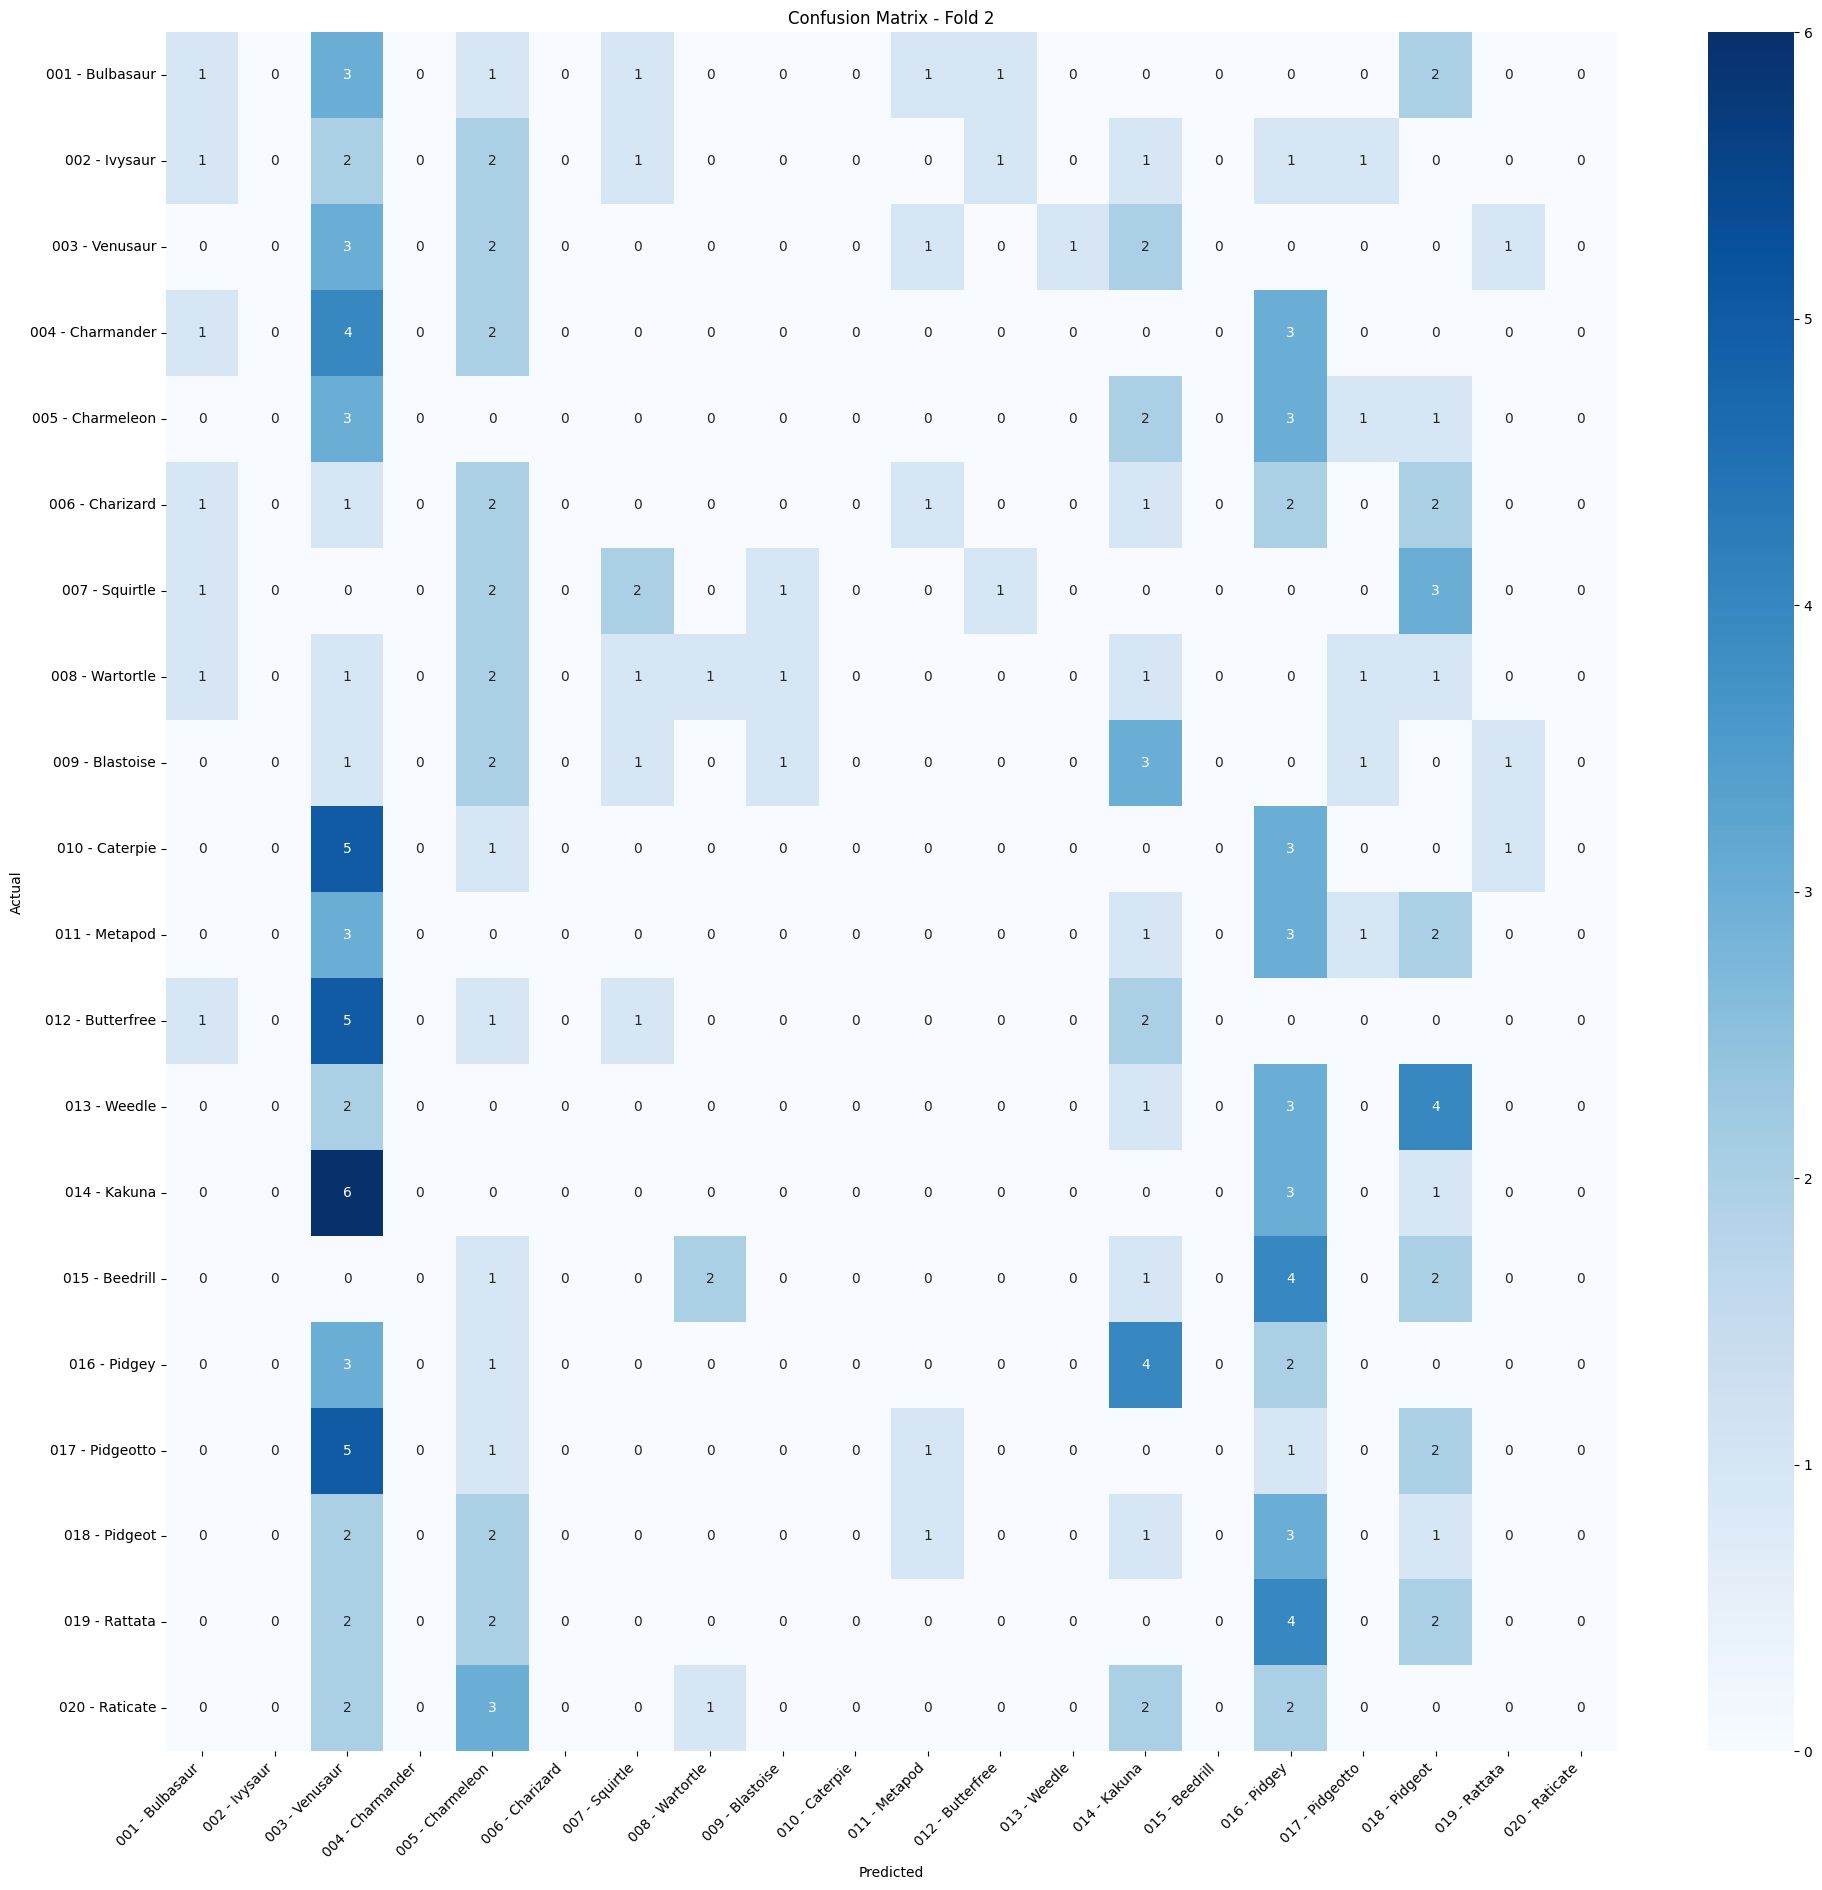

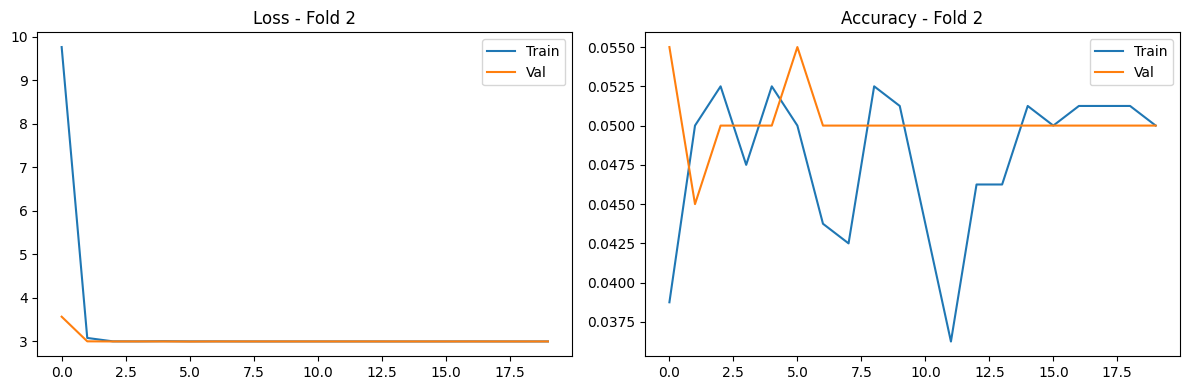

Fold 3/5
  Epoch 01/20 | Train Loss: 9.0782 Acc: 0.0500 | Val Loss: 4.3244 Acc: 0.0750
  Epoch 02/20 | Train Loss: 3.1322 Acc: 0.0450 | Val Loss: 3.0069 Acc: 0.0550
  Epoch 03/20 | Train Loss: 3.0237 Acc: 0.0500 | Val Loss: 2.9927 Acc: 0.0550
  Epoch 04/20 | Train Loss: 3.0005 Acc: 0.0413 | Val Loss: 2.9984 Acc: 0.0550
  Epoch 05/20 | Train Loss: 2.9981 Acc: 0.0450 | Val Loss: 2.9951 Acc: 0.0550
  Epoch 06/20 | Train Loss: 2.9925 Acc: 0.0537 | Val Loss: 2.9613 Acc: 0.0700
  Epoch 07/20 | Train Loss: 2.9894 Acc: 0.0512 | Val Loss: 2.9534 Acc: 0.0750
  Epoch 08/20 | Train Loss: 2.9894 Acc: 0.0663 | Val Loss: 2.9496 Acc: 0.0850
  Epoch 09/20 | Train Loss: 2.9795 Acc: 0.0600 | Val Loss: 2.9504 Acc: 0.0800
  Epoch 10/20 | Train Loss: 2.9776 Acc: 0.0600 | Val Loss: 2.9451 Acc: 0.0850
  Epoch 11/20 | Train Loss: 2.9807 Acc: 0.0625 | Val Loss: 2.9438 Acc: 0.0800
  Epoch 12/20 | Train Loss: 2.9779 Acc: 0.0638 | Val Loss: 2.9412 Acc: 0.0850
  Epoch 13/20 | Train Loss: 2.9734 Acc: 0.0663 | Val Lo

/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

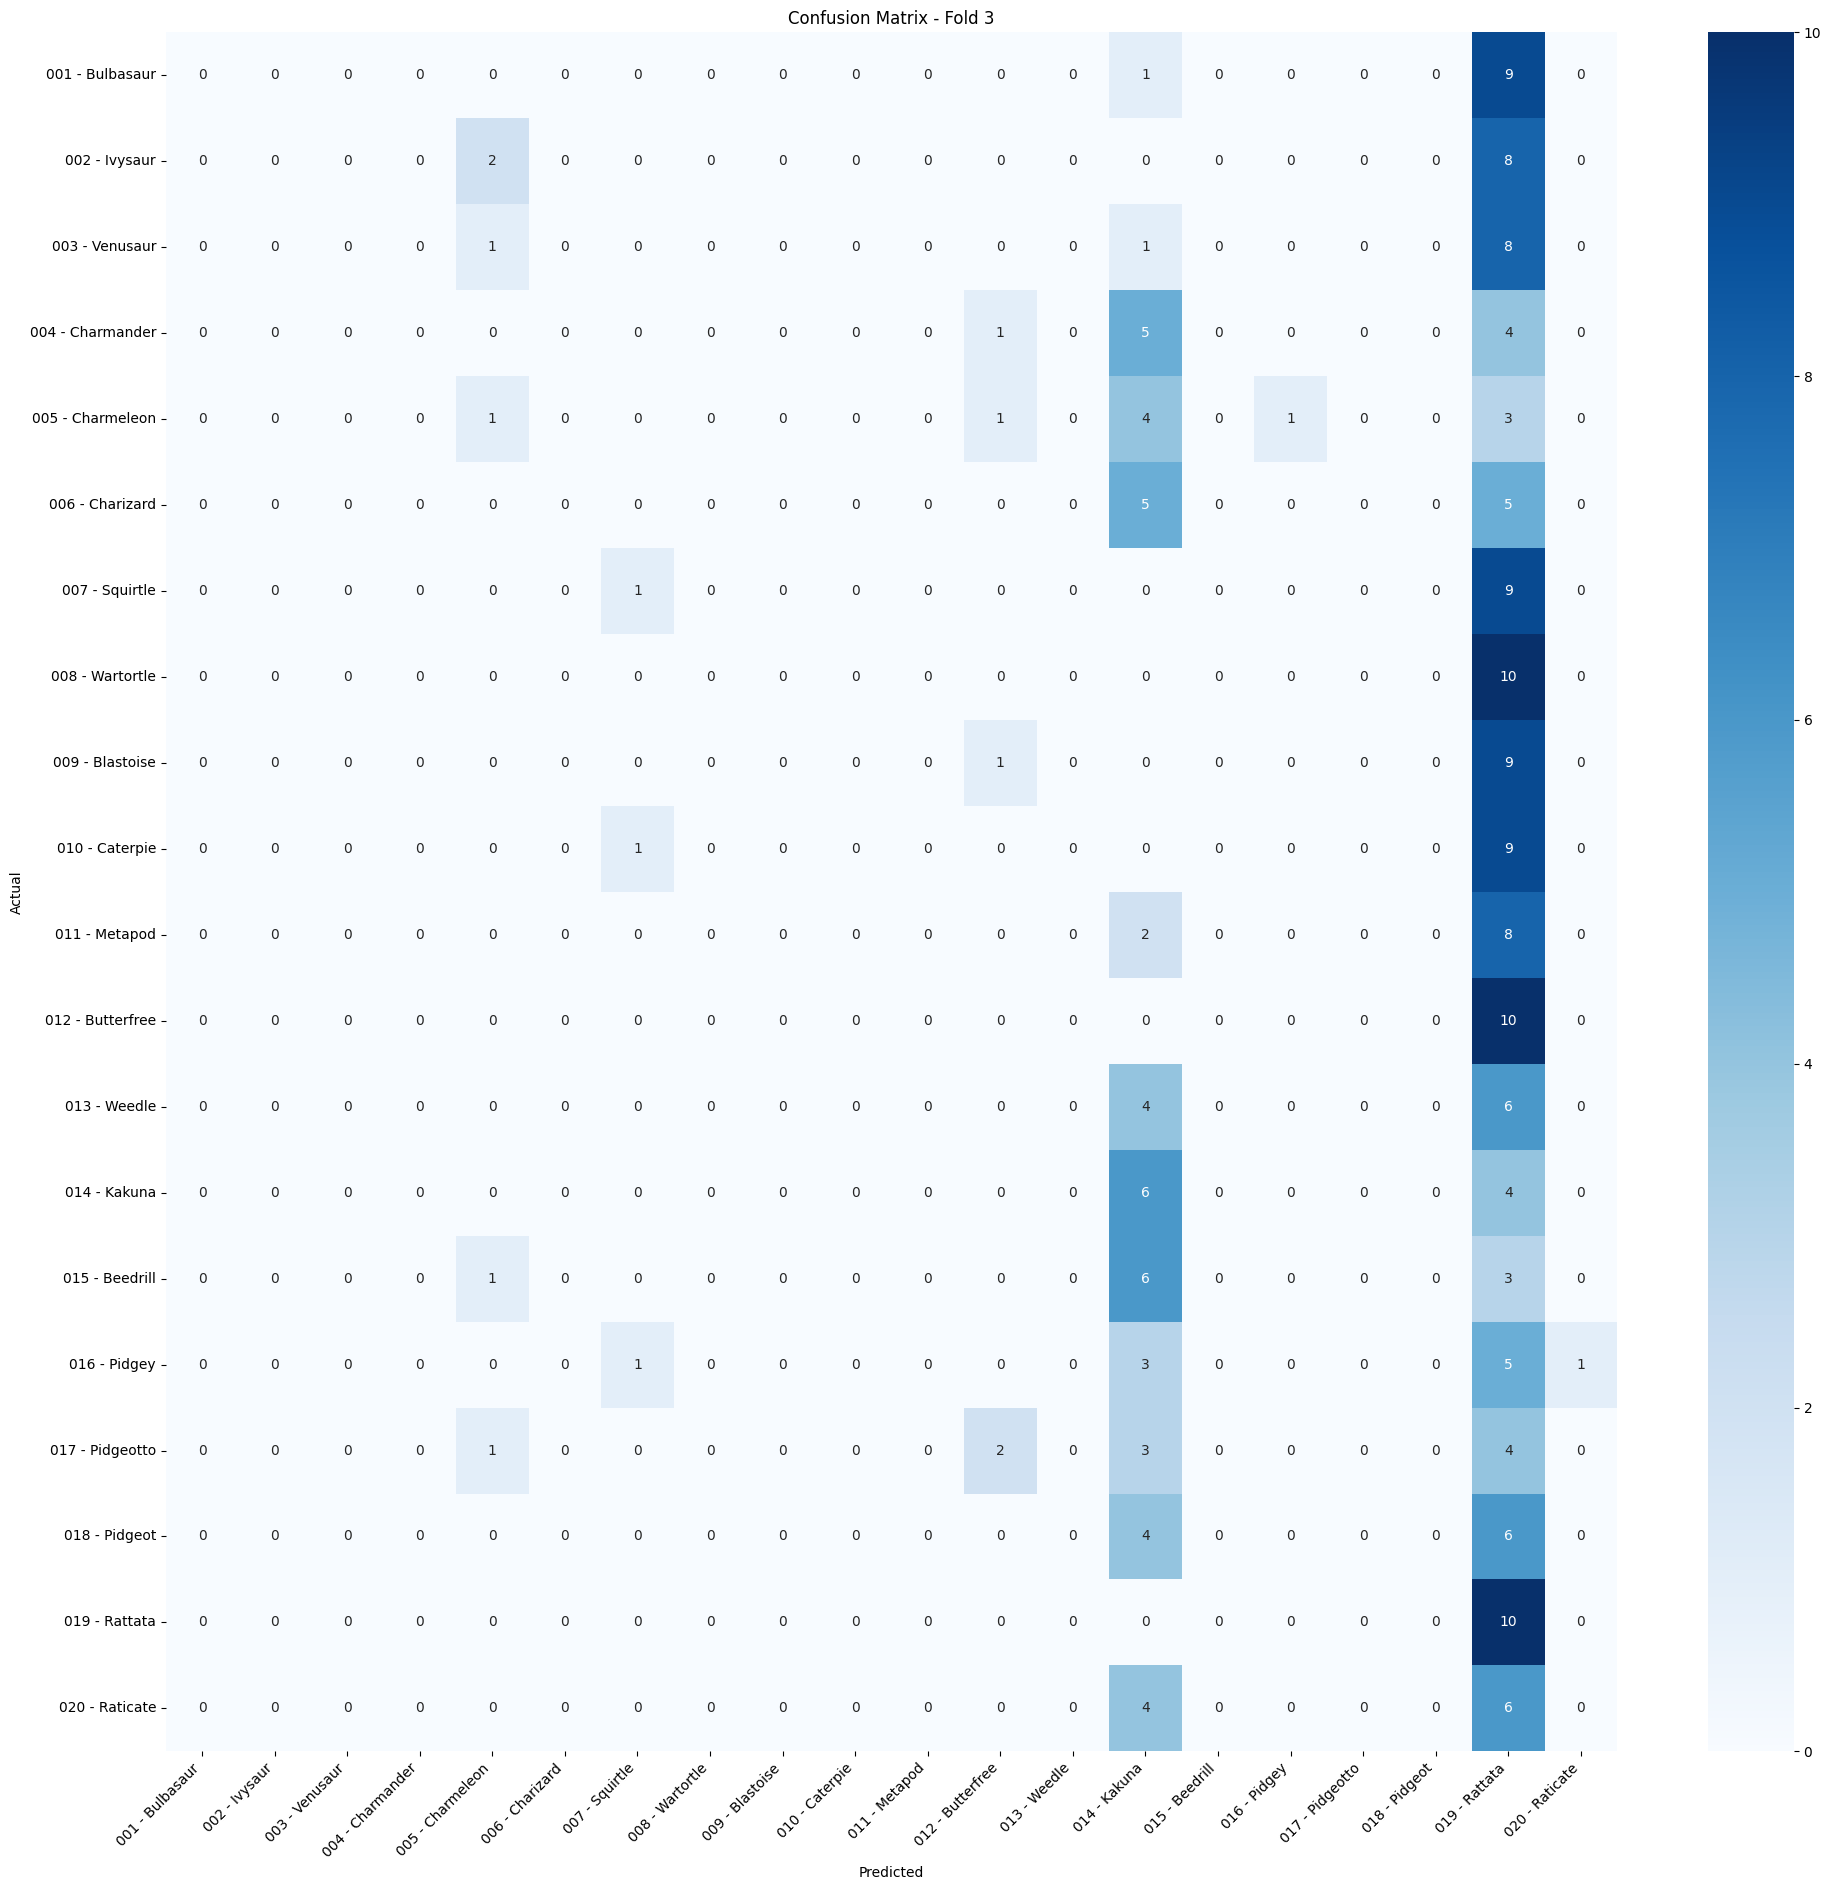

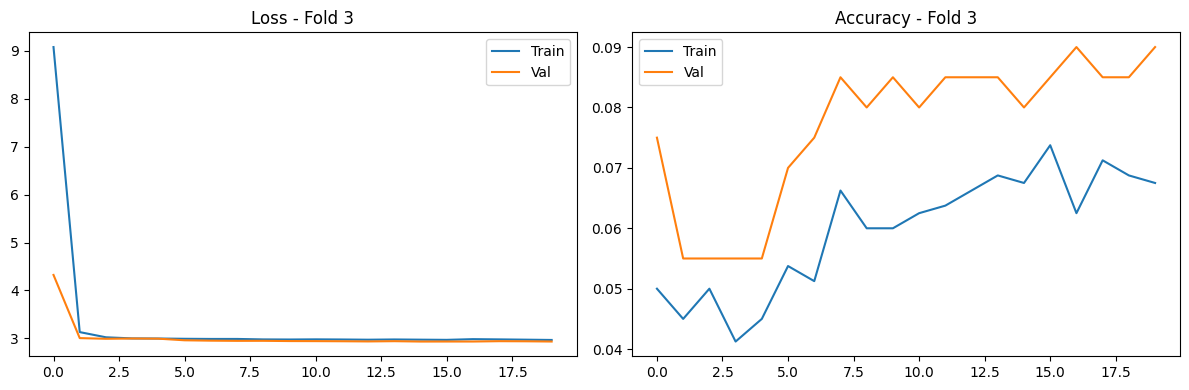

Fold 4/5
  Epoch 01/20 | Train Loss: 9.9618 Acc: 0.0650 | Val Loss: 4.1408 Acc: 0.0700
  Epoch 02/20 | Train Loss: 3.5328 Acc: 0.0425 | Val Loss: 2.9836 Acc: 0.0500
  Epoch 03/20 | Train Loss: 2.9891 Acc: 0.0550 | Val Loss: 2.9740 Acc: 0.0400
  Epoch 04/20 | Train Loss: 3.0159 Acc: 0.0525 | Val Loss: 2.9812 Acc: 0.0550
  Epoch 05/20 | Train Loss: 2.9946 Acc: 0.0437 | Val Loss: 2.9914 Acc: 0.0500
  Epoch 06/20 | Train Loss: 2.9969 Acc: 0.0462 | Val Loss: 2.9719 Acc: 0.0550
  Epoch 07/20 | Train Loss: 3.0109 Acc: 0.0512 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 08/20 | Train Loss: 2.9963 Acc: 0.0488 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 09/20 | Train Loss: 2.9946 Acc: 0.0512 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 10/20 | Train Loss: 2.9956 Acc: 0.0500 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 11/20 | Train Loss: 2.9964 Acc: 0.0512 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 12/20 | Train Loss: 2.9960 Acc: 0.0500 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 13/20 | Train Loss: 2.9955 Acc: 0.0500 | Val Lo

/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

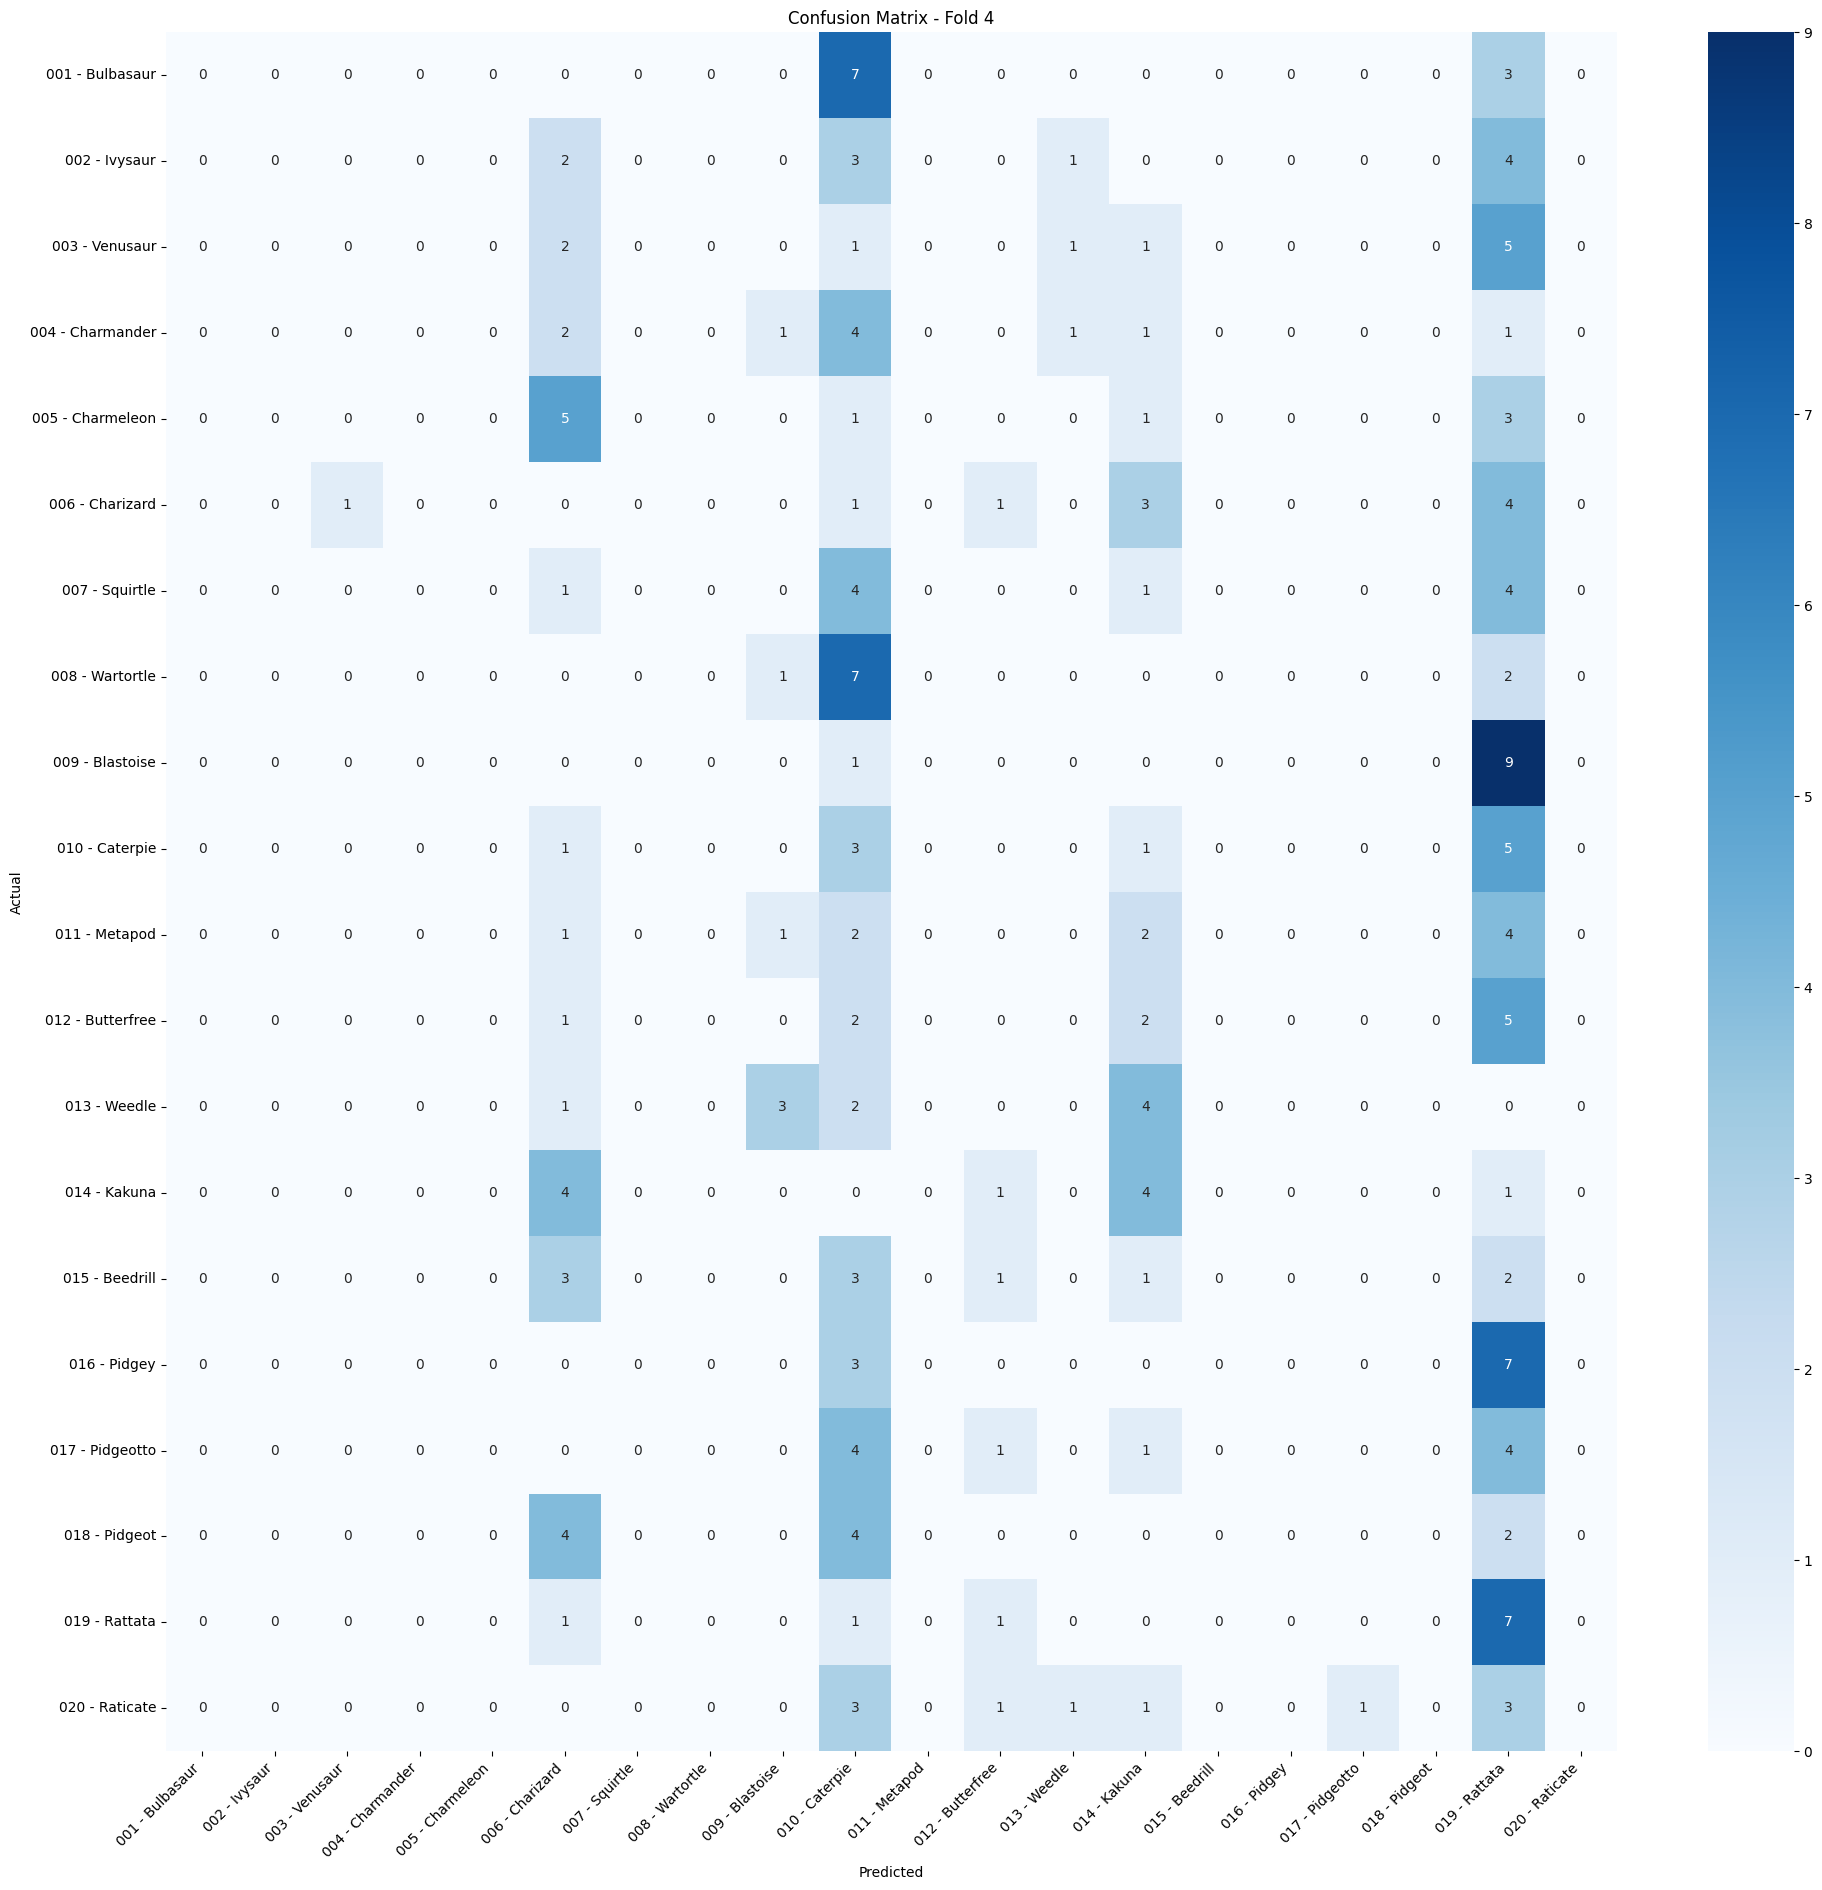

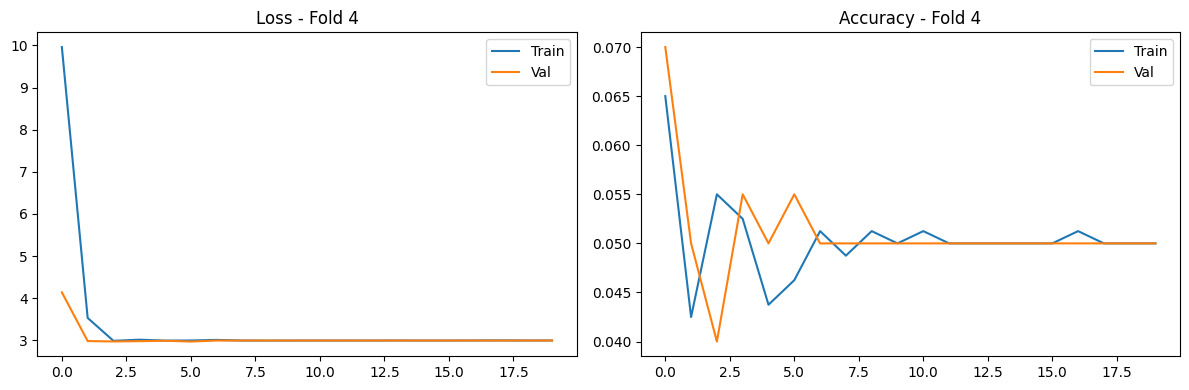

Fold 5/5
  Epoch 01/20 | Train Loss: 7.7667 Acc: 0.0525 | Val Loss: 3.0875 Acc: 0.0300
  Epoch 02/20 | Train Loss: 3.0266 Acc: 0.0462 | Val Loss: 2.9884 Acc: 0.0750
  Epoch 03/20 | Train Loss: 2.9978 Acc: 0.0600 | Val Loss: 2.9959 Acc: 0.0500
  Epoch 04/20 | Train Loss: 2.9950 Acc: 0.0512 | Val Loss: 2.9843 Acc: 0.0600
  Epoch 05/20 | Train Loss: 2.9952 Acc: 0.0437 | Val Loss: 2.9961 Acc: 0.0550
  Epoch 06/20 | Train Loss: 3.0030 Acc: 0.0437 | Val Loss: 2.9873 Acc: 0.0350
  Epoch 07/20 | Train Loss: 2.9934 Acc: 0.0587 | Val Loss: 2.9885 Acc: 0.0450
  Epoch 08/20 | Train Loss: 2.9903 Acc: 0.0413 | Val Loss: 2.9872 Acc: 0.0500
  Epoch 09/20 | Train Loss: 2.9932 Acc: 0.0575 | Val Loss: 2.9861 Acc: 0.0600
  Epoch 10/20 | Train Loss: 2.9940 Acc: 0.0450 | Val Loss: 2.9832 Acc: 0.0750
  Epoch 11/20 | Train Loss: 2.9921 Acc: 0.0537 | Val Loss: 2.9774 Acc: 0.1000
  Epoch 12/20 | Train Loss: 2.9898 Acc: 0.0625 | Val Loss: 2.9720 Acc: 0.0900
  Epoch 13/20 | Train Loss: 2.9929 Acc: 0.0537 | Val Lo

/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/viviteto/Desktop/school/pokemon-image-classification/environments/ml-env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

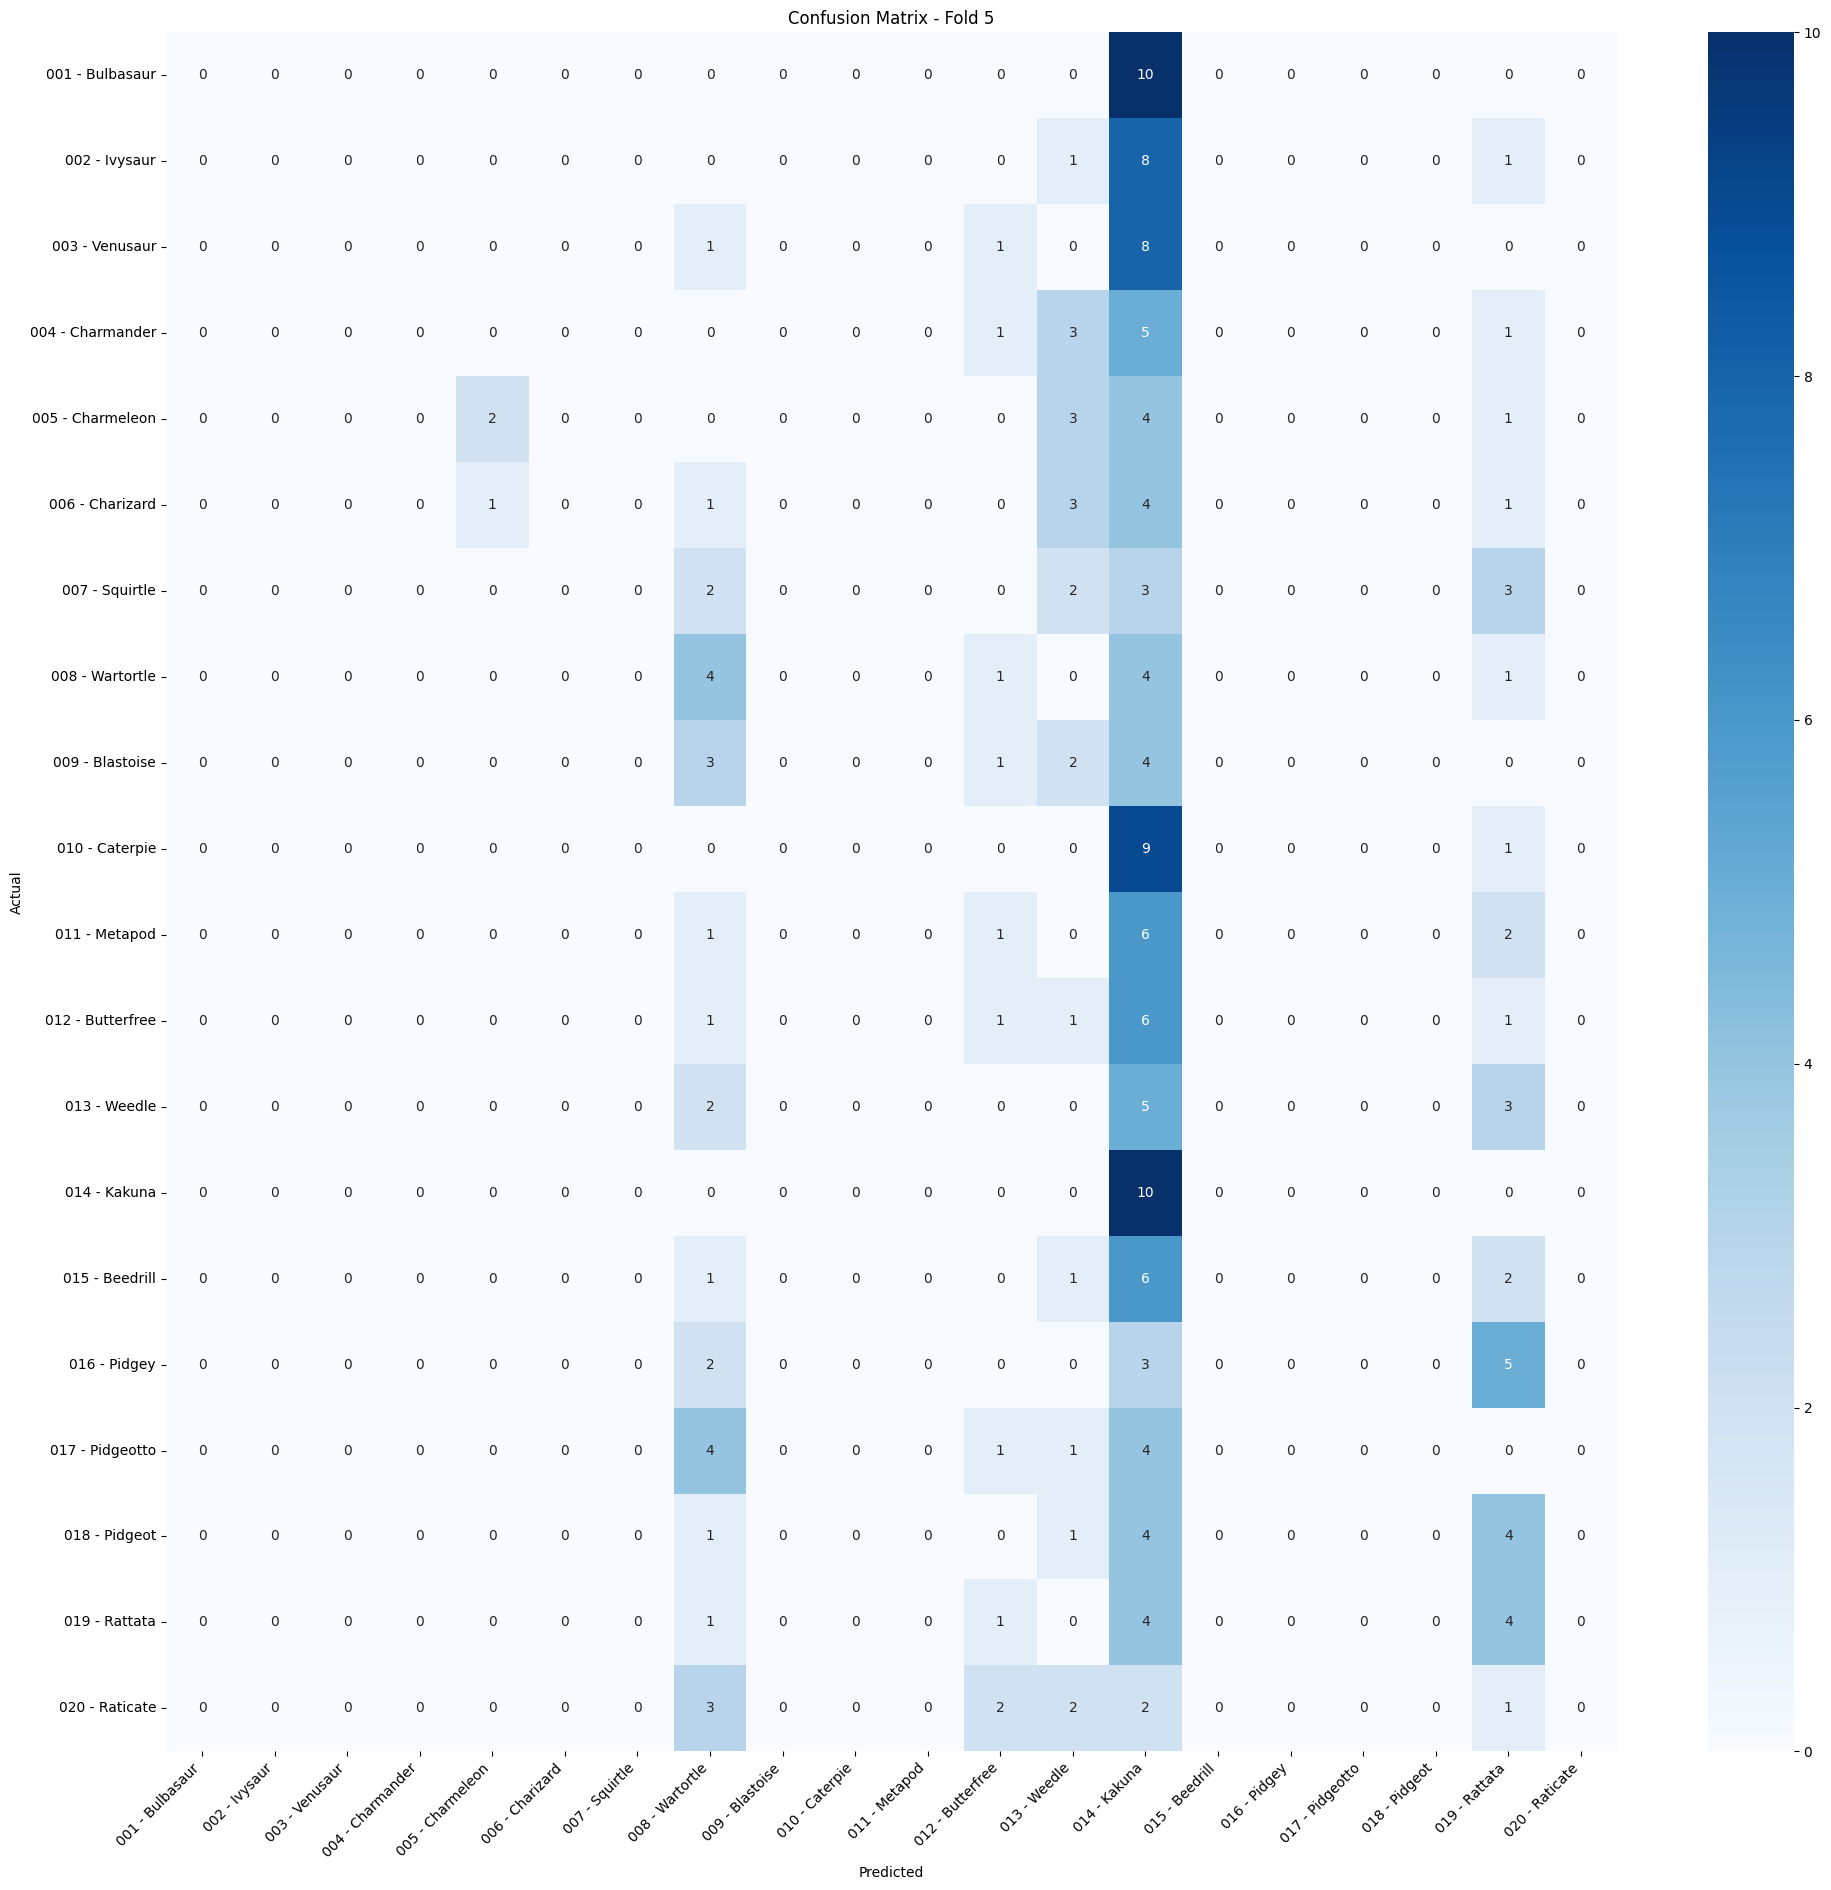

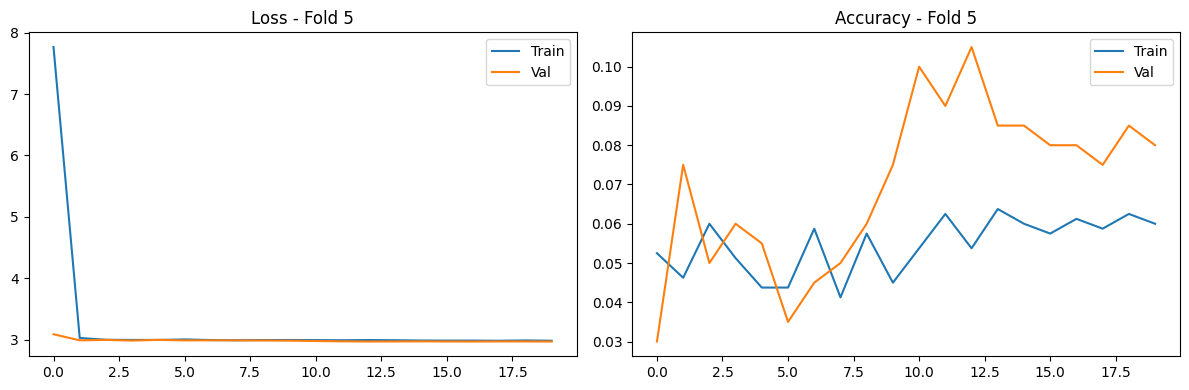


Cross-Validation Results
  Fold 1: 0.0950
  Fold 2: 0.0550
  Fold 3: 0.0900
  Fold 4: 0.0700
  Fold 5: 0.1050

  Mean: 0.0830
  Std:  0.0181


In [4]:
paths, labels, class_names = load_paths_and_labels(DATA_DIR)
num_classes = len(class_names)
print(f"Found {len(paths)} images | {num_classes} classes: {class_names}\n")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(paths, labels), 1):
    print(f"{'='*50}")
    print(f"Fold {fold}/{N_FOLDS}")
    print(f"{'='*50}")

    train_paths  = [paths[i]  for i in train_idx]
    train_labels = [labels[i] for i in train_idx]
    val_paths    = [paths[i]  for i in val_idx]
    val_labels   = [labels[i] for i in val_idx]

    train_dataset = PokemonDataset(train_paths, train_labels, train_transform)
    val_dataset   = PokemonDataset(val_paths,   val_labels,   val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model     = CNN(num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    best_val_acc = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, preds, true = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_preds, best_true = preds, true
            torch.save(model.state_dict(), f"best_model_fold{fold}.pt")

        print(f"  Epoch {epoch:02d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    fold_accuracies.append(best_val_acc)
    print(f"\nFold {fold} best val accuracy: {best_val_acc:.4f}")
    print(classification_report(best_true, best_preds, target_names=class_names))
    plot_confusion_matrix(best_true, best_preds, class_names, fold=fold)

    # Loss curve per fold
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"Loss - Fold {fold}")
    ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"Accuracy - Fold {fold}")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f"curves_fold{fold}.png", dpi=150)
    plt.show()

print(f"\n{'='*50}")
print(f"Cross-Validation Results")
print(f"{'='*50}")
for i, acc in enumerate(fold_accuracies, 1):
    print(f"  Fold {i}: {acc:.4f}")
print(f"\n  Mean: {np.mean(fold_accuracies):.4f}")
print(f"  Std:  {np.std(fold_accuracies):.4f}")
